## <span style="color:#db7d60">Setup</span>

In [ ]:
%load_ext autoreload
%autoreload 2

import json
import math
import pickle
import numpy as np
import pandas as pd
import textwrap
import sys
from pathlib import Path
from IPython.display import display, Markdown
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter, FuncFormatter
import seaborn as sns
from scipy.signal import savgol_filter

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

import pUtil
from analysis_common import *
import data_manager
import analysis as anal

import vector
from particle import Particle
from particle import PDGID

plt.rcParams['figure.figsize'] = (21, 6)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

# ---- Global seaborn style ----
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font_scale=1.1
)

In [84]:
def set_pub_style(*, context="paper", font="serif", base_fontsize=10, dpi=200, use_tex=False):   # set True if you have a working LaTeX install
    # Seaborn baseline
    sns.set_theme(context=context, style="ticks")

    # Colorblind-friendly palette (great default for journals)
    sns.set_palette("colorblind")

    # Matplotlib rcParams tuned for print
    mpl.rcParams.update({
        # Figure + save
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
        "savefig.bbox": "tight",
        "savefig.transparent": True,   # keeps backgrounds clean in PDFs
        "pdf.fonttype": 42,            # embed TrueType fonts
        "ps.fonttype": 42,

        # Typography
        "font.family": font,
        "font.size": base_fontsize,
        "axes.titlesize": base_fontsize + 1,
        "axes.labelsize": base_fontsize + 1,
        "xtick.labelsize": base_fontsize,
        "ytick.labelsize": base_fontsize,
        "legend.fontsize": base_fontsize,
        "legend.title_fontsize": base_fontsize,

        # Axes + lines
        "axes.linewidth": 0.9,
        "lines.linewidth": 1.8,
        "lines.markersize": 5,

        # Ticks (major + minor)
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.minor.width": 0.8,
        "ytick.minor.width": 0.8,

        # Grid (usually off for journal plots; enable per-figure if needed)
        "axes.grid": False,

        # Legend
        "legend.frameon": False,

        # Math text
        "mathtext.fontset": "stix",
        "font.serif": ["STIXGeneral", "Times New Roman", "Times", "DejaVu Serif"],
        "text.usetex": use_tex,
    })

    # Remove top/right spines for a clean physics look
    sns.despine(trim=True)

set_pub_style(base_fontsize=10, dpi=250, use_tex=False)

<Figure size 5250x1500 with 0 Axes>

## <span style="color:#db7d60">Analysis</span>

In [104]:
anal.plotting.default_figsize = (3.35, 3.8)  # single-column friendly
anal.plotting.default_dpi = 100

def _apply_dynamic_count_scaling(ax, y_arrays, base_label="Counts", group_by_3=False):
    y_all = np.concatenate([np.asarray(y) for y in y_arrays if y is not None])
    y_max = np.nanmax(y_all) if y_all.size else 0
    if not np.isfinite(y_max) or y_max <= 0:
        ax.set_ylabel(base_label)
        return

    order = int(np.floor(np.log10(y_max)))
    if group_by_3:
        order = int(np.floor(order / 3) * 3)
    scale = 10 ** order

    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/scale:g}"))
    # ax.set_ylabel(f"{base_label} (×10$^{{{order}}}$)")
    ax.set_ylabel(rf"Counts ($\times 10^{{{order}}}$)")
    
def place_legend_emptiest_corner(ax, x, y, labels, colors=None, lw=2, fontsize=10):
    """
    Choose legend location among 4 corners by finding the corner with minimal summed y
    in that x-range and near-top y-range. Works well for peaked distributions.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # Define corner x-windows as fractions of axis span
    xL0, xL1 = xmin + 0.00*(xmax-xmin), xmin + 0.35*(xmax-xmin)
    xR0, xR1 = xmin + 0.65*(xmax-xmin), xmin + 1.00*(xmax-xmin)

    # Score corners by "how much curve lives there"
    def score(x0, x1):
        m = (x >= x0) & (x <= x1)
        if not np.any(m):
            return np.inf
        return np.nansum(y[m])

    scores = {
        "upper left":  score(xL0, xL1),
        "upper right": score(xR0, xR1),
        "lower left":  score(xL0, xL1) + 1e9,   # discourage lower corners for hists usually
        "lower right": score(xR0, xR1) + 1e9,
    }

    best_loc = min(scores, key=scores.get)
    
    # This is here to move the left corner slightly rightwards to avoid clashing with the panel labels
    if best_loc == "upper left":
        leg = ax.legend(loc="upper left", bbox_to_anchor=(0.03, 0.98), frameon=False, fontsize=fontsize)
    else:
        leg = ax.legend(loc="upper right", bbox_to_anchor=(0.98, 0.98), frameon=False, fontsize=fontsize)

    # leg = ax.legend(loc=best_loc, frameon=False, fontsize=fontsize)
    return leg
    
def _get_labels(column_name):
        # assert column_name in plotting.verbose_columns, f"Invalid column name: {column_name}. Must be one of {plotting.verbose_columns}."
        
        if column_name == 'num_particles':
            feature_name = 'Number of particles'
            unit = ''
            return feature_name, unit
        
        unit = ''
        if column_name in ['e', 'pt', 'px', 'py', 'pz']:
            unit = '[MeV]'
                        
        feature_name = column_name
        if column_name == 'pt':
            feature_name = r'$p_{T}$'
        elif column_name == 'px':
            feature_name = r'$p_{x}$'
        elif column_name == 'py':
            feature_name = r'$p_{y}$'
        elif column_name == 'pz':
            feature_name = r'$p_{z}$'
        elif column_name == 'eta':
            feature_name = r'$\eta$'
        elif column_name == 'theta':
            feature_name = r'$\theta$'
        elif column_name == 'phi':
            feature_name = r'$\phi$'
        return feature_name, unit
    
def _plot_dist_and_ratio(
    *,
    column_name,
    feature_name,
    unit,
    edges,
    real_vals,
    gen_vals_by_model,          # dict: model_name -> np.array
    model_legend_titles,        # ["Geant4", "model1 label", "model2 label", ...] aligned with model_names
    model_names,                # list[str]
    normalized=False,
    use_log=False,
    out_file=None,
    title=None,
    ratio_ylim=(0.5, 1.5),
    ratio_bands=(0.05, 0.10, 0.20),
    dynamic_count_scale=True,
    count_scale_group_by_3=False,
    dpi=200,
):
    sns.set_theme(style="ticks", context="paper")
    palette = sns.color_palette("colorblind", n_colors=max(3, len(model_names) + 1))

    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    fig, (axd, axr) = plt.subplots(
        2, 1,
        figsize=(8, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        constrained_layout=True,
        dpi=dpi
    )

    if title:
        fig.suptitle(title, fontsize=12)

    # Labels
    if normalized:
        axd.set_ylabel("Density")
    else:
        axd.set_ylabel("log(Counts)" if use_log else "Counts")

    axr.set_ylabel("Gen / Geant4")
    axr.set_xlabel(f"{feature_name} {unit}".rstrip())

    axd.set_yscale("log" if use_log else "linear")

    for ax in (axd, axr):
        ax.minorticks_on()
        ax.tick_params(which="both", direction="in", top=True, right=True)
    
    axd.yaxis.set_major_locator(mticker.MaxNLocator(6))
    axr.yaxis.set_major_locator(mticker.MultipleLocator(0.1))

    # --- Reference (Geant4) ---
    real_vals = np.asarray(real_vals)
    rcounts, _ = np.histogram(real_vals, bins=edges)
    rN = np.sum(rcounts)

    if normalized:
        r_y = rcounts / (rN * widths) if rN > 0 else np.zeros_like(rcounts, dtype=float)
        r_err = np.sqrt(rcounts) / (rN * widths) if rN > 0 else np.zeros_like(rcounts, dtype=float)
    else:
        r_y = rcounts.astype(float)
        r_err = np.sqrt(rcounts)

    axd.stairs(r_y, edges, color="black", linewidth=2.2,
               label=f"{model_legend_titles[0]} | N={rN}", zorder=4)

    mask_r = rcounts > 0
    axd.errorbar(
        centers[mask_r], r_y[mask_r], yerr=r_err[mask_r],
        fmt="none", ecolor="black", elinewidth=0.9, capsize=0, alpha=0.9, zorder=5
    )

    # Ratio denominator (densities, shape-only)
    r_density = rcounts / rN if rN > 0 else np.zeros_like(rcounts, dtype=float)
    r_density_err = np.sqrt(rcounts) / rN if rN > 0 else np.zeros_like(rcounts, dtype=float)

    top_y_arrays = [r_y]

    # --- Models ---
    for i, mn in enumerate(model_names):
        gvals = np.asarray(gen_vals_by_model[mn])
        gcounts, _ = np.histogram(gvals, bins=edges)
        gN = np.sum(gcounts)

        if normalized:
            g_y = gcounts / (gN * widths) if gN > 0 else np.zeros_like(gcounts, dtype=float)
            g_err = np.sqrt(gcounts) / (gN * widths) if gN > 0 else np.zeros_like(gcounts, dtype=float)
        else:
            g_y = gcounts.astype(float)
            g_err = np.sqrt(gcounts)

        top_y_arrays.append(g_y)

        color = palette[i + 1]
        axd.stairs(
            g_y, edges, linewidth=2.0, color=color,
            label=f"{model_legend_titles[i+1]} | N={gN}", zorder=2
        )

        mask_g = gcounts > 0
        axd.errorbar(
            centers[mask_g], g_y[mask_g], yerr=g_err[mask_g],
            fmt="none", ecolor=color, elinewidth=0.8, capsize=0, alpha=0.9, zorder=3
        )

        # Ratio (densities)
        g_density = gcounts / gN if gN > 0 else np.zeros_like(gcounts, dtype=float)
        g_density_err = np.sqrt(gcounts) / gN if gN > 0 else np.zeros_like(gcounts, dtype=float)

        ratio = np.divide(g_density, r_density, out=np.full_like(g_density, np.nan, dtype=float), where=r_density > 0)

        # Error propagation on ratio
        ratio_err = np.full_like(ratio, np.nan, dtype=float)
        ok = (g_density > 0) & (r_density > 0)
        ratio_err[ok] = ratio[ok] * np.sqrt(
            (g_density_err[ok] / g_density[ok])**2 + (r_density_err[ok] / r_density[ok])**2
        )

        axr.stairs(ratio, edges, linewidth=1.6, color=color, zorder=2)
        ok2 = np.isfinite(ratio) & np.isfinite(ratio_err)
        axr.errorbar(
            centers[ok2], ratio[ok2], yerr=ratio_err[ok2],
            fmt="none", ecolor=color, elinewidth=0.8, capsize=0, alpha=0.9, zorder=3
        )
        
    axd.text(0.01, 0.95, "(a)", transform=axd.transAxes, fontsize=11, va="top")
    axr.text(0.01, 0.95, "(b)", transform=axr.transAxes, fontsize=11, va="top")

    # Ratio guide lines
    axr.axhline(1.0, color="0.25", lw=1.2)
    for frac in [0.05, 0.10]:
        axr.axhline(1.0 + frac, color="0.6", linestyle="--", lw=0.8, alpha=0.6)
        axr.axhline(1.0 - frac, color="0.6", linestyle="--", lw=0.8, alpha=0.6)
    axr.set_ylim(*ratio_ylim)

    # Dynamic y scaling for counts (not density, not log)
    if dynamic_count_scale and (not normalized) and (not use_log):
        _apply_dynamic_count_scaling(axd, top_y_arrays, base_label="Counts", group_by_3=count_scale_group_by_3)

    # axd.legend(loc="best", frameon=False)
    
    # Choose legend position dynamically (based on reference curve)
    x_for_score = 0.5 * (edges[:-1] + edges[1:])
    y_for_score = r_y   # use Geant4 reference to avoid peak overlap

    place_legend_emptiest_corner(axd, x_for_score, y_for_score, labels=None, fontsize=9)

    sns.despine(ax=axd, trim=True)
    sns.despine(ax=axr, trim=True)

    if out_file is not None:
        fig.savefig(out_file, bbox_inches="tight")
    plt.show()
    return fig, (axd, axr)

In [ ]:
# Custom formatter to force scientific notation for small numbers
def sci_notation(x, pos):
    return f'{x:.0e}'

def compare_distributions_all(
    model_names,
    model_legend_titles,
    column_name=None,
    normalized=False,
    use_log=False,
    out_file=None,
):
    # Labels/units
    feature_name, unit = _get_labels(column_name)

    # Common bins from first model
    bin_settings = anal.plotting.get_common_data(model_names[0])
    x_min = bin_settings[column_name]["min"]
    x_max = bin_settings[column_name]["max"]
    n_bins = bin_settings[column_name]["bins"]
    edges = np.linspace(x_min, x_max, n_bins + 1)

    relevant_column_pos = anal.plotting.verbose_columns.index(column_name)

    # --- Real: all outgoing particles ---
    real_verbose_data = data_manager.load_verbose_dataset(
        pUtil.get_model_preparation_dir(model_names[0]) / "real_verbose_test_particles.csv",
        pad_token=np.nan
    )
    real_vals = []
    for event in real_verbose_data:
        for particle in event[1:]:
            v = particle[relevant_column_pos]
            if not np.isnan(v):
                real_vals.append(v)

    # --- Generated: all outgoing particles ---
    gen_vals_by_model = {}
    for mn in model_names:
        sampled_verbose_data = data_manager.load_verbose_dataset(
            pUtil.get_latest_sampling_dir(mn) / "untokenized_samples_verbose.csv",
            pad_token=np.nan
        )
        vals = []
        for event in sampled_verbose_data:
            for particle in event[1:]:
                v = particle[relevant_column_pos]
                if not np.isnan(v):
                    vals.append(v)
        gen_vals_by_model[mn] = np.asarray(vals)

    title = None # f"{feature_name} Distribution (All Outgoing Particles)"

    return _plot_dist_and_ratio(
        column_name=column_name,
        feature_name=feature_name,
        unit=unit,
        edges=edges,
        real_vals=np.asarray(real_vals),
        gen_vals_by_model=gen_vals_by_model,
        model_legend_titles=model_legend_titles,
        model_names=model_names,
        normalized=normalized,
        use_log=use_log,
        out_file=out_file,
        title=title,
        dpi=anal.plotting.default_dpi,
    )

def compare_distributions_leading(
    model_names,
    model_legend_titles,
    column_name=None,
    normalized=False,
    use_log=False,
    out_file=None,
):
    feature_name, unit = _get_labels(column_name)

    # Common bins from first model
    bin_settings = anal.plotting.get_common_data(model_names[0])
    x_min = bin_settings[column_name]["min"]
    x_max = bin_settings[column_name]["max"]
    n_bins = bin_settings[column_name]["bins"]
    edges = np.linspace(x_min, x_max, n_bins + 1)

    relevant_column_pos = anal.plotting.verbose_columns.index(column_name)

    # --- Real: leading particle only (highest energy among secondaries[:,1]) ---
    real_verbose_data = data_manager.load_verbose_dataset(
        pUtil.get_model_preparation_dir(model_names[0]) / "real_verbose_test_particles.csv",
        pad_token=np.nan
    )
    real_vals = []
    for event in real_verbose_data:
        secondaries = event[1:]
        if len(secondaries) == 0:
            continue
        leading_idx = np.nanargmax(secondaries[:, 1])
        leading = secondaries[leading_idx]
        v = leading[relevant_column_pos]
        if not np.isnan(v):
            real_vals.append(v)

    # --- Generated: leading particle only ---
    gen_vals_by_model = {}
    for mn in model_names:
        sampled_verbose_data = data_manager.load_verbose_dataset(
            pUtil.get_latest_sampling_dir(mn) / "untokenized_samples_verbose.csv",
            pad_token=np.nan
        )
        vals = []
        for event in sampled_verbose_data:
            secondaries = event[1:]
            if len(secondaries) == 0:
                continue
            leading_idx = np.nanargmax(secondaries[:, 1])
            leading = secondaries[leading_idx]
            v = leading[relevant_column_pos]
            if not np.isnan(v):
                vals.append(v)
        gen_vals_by_model[mn] = np.asarray(vals)

    title = None # f"{feature_name} Distribution (Leading Particle)"

    return _plot_dist_and_ratio(
        column_name=column_name,
        feature_name=feature_name,
        unit=unit,
        edges=edges,
        real_vals=np.asarray(real_vals),
        gen_vals_by_model=gen_vals_by_model,
        model_legend_titles=model_legend_titles,
        model_names=model_names,
        normalized=normalized,
        use_log=use_log,
        out_file=out_file,
        title=title,
        dpi=anal.plotting.default_dpi,
    )

def ema(y, alpha=0.02):
    y = np.asarray(y, dtype=float)
    out = np.empty_like(y)
    out[0] = y[0]
    for i in range(1, len(y)):
        out[i] = alpha*y[i] + (1-alpha)*out[i-1]
    return out

def smooth_rolling(y, window=101, method="median_then_mean"):
    """
    window should be odd. Try 101–401 depending on noise.
    """
    s = pd.Series(np.asarray(y, dtype=float))
    if method == "median_then_mean":
        y1 = s.rolling(window, center=True, min_periods=1).median()
        y2 = y1.rolling(window, center=True, min_periods=1).mean()
        return y2.to_numpy()
    elif method == "median":
        return s.rolling(window, center=True, min_periods=1).median().to_numpy()
    elif method == "mean":
        return s.rolling(window, center=True, min_periods=1).mean().to_numpy()
    else:
        raise ValueError("Unknown method")
    
def smooth_savgol(y, window=301, poly=3):
    window = int(window)
    if window % 2 == 0:
        window += 1
    y = np.asarray(y, dtype=float)
    # if too short, fallback
    if len(y) < window:
        return y
    return savgol_filter(y, window_length=window, polyorder=poly, mode="interp")

def smooth_bin_average(x, y, bin_size=25):
    x = np.asarray(x)
    y = np.asarray(y, dtype=float)
    n = len(y)
    m = n // bin_size
    x2 = x[:m*bin_size].reshape(m, bin_size).mean(axis=1)
    y2 = y[:m*bin_size].reshape(m, bin_size).mean(axis=1)
    return x2, y2

def plot_validation_run_pub(
    model_names,
    model_legend_title,
    y_lim=None,
    x_lim=None,
    use_log=False,
    out_file=None,
    plot_lr_schedule=False,
    figsize=(6.9, 3.2),          # 2-column friendly
    show_raw=True,
    smooth_alpha=0.02,
    mark_best=True,
):
    if not isinstance(model_names, list):
        model_names = [model_names]

    sns.set_theme(style="ticks", context="paper")
    fig, ax = plt.subplots(figsize=figsize, dpi=anal.plotting.default_dpi)

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Validation loss")

    if y_lim is not None:
        ax.set_ylim(y_lim)
    if x_lim is not None:
        ax.set_xlim(x_lim)
    if use_log:
        ax.set_yscale("log")

    ax.minorticks_on()
    ax.tick_params(which="both", direction="in", top=True, right=True)

    # very light grid (optional)
    ax.grid(True, which="major", alpha=0.25, linewidth=0.8)
    ax.grid(True, which="minor", alpha=0.12, linewidth=0.6)

    lrax = None

    for idx, model_name in enumerate(model_names):
        model_data = anal.tables.get_all_data(model_name)
        df = model_data.running_df
        x = np.asarray(df["iter"])
        y = np.asarray(df["val_loss"])

        color = anal.plotting.colors[idx]

        # Optional LR on twin axis (keep subtle)
        if plot_lr_schedule:
            config_filepath = pUtil.get_model_config_filepath(model_name)
            with open(config_filepath, "r") as f:
                model_config = json.load(f)
                training_conf = model_config.get("training_config", {})
                lr_scheduler = training_conf.get("lr_scheduler", "cosine_annealing_with_warmup")
                warmup_iters = training_conf.get("warmup_iters", 0)
                lr_decay_iters = training_conf.get("lr_decay_iters", 0)
                learning_rate = training_conf.get("learning_rate", 0)
                min_lr = training_conf.get("min_lr", 0)
                base_lr_decay_mult = training_conf.get("base_lr_decay_mult", 1)
                cycle_steps_mult = training_conf.get("cycle_steps_mult", 1)

            iters = np.arange(df["iter"].max())
            lrs = [
                anal.plotting._get_lr(it, lr_scheduler, warmup_iters, lr_decay_iters,
                                      min_lr, learning_rate, cycle_steps_mult, base_lr_decay_mult)
                for it in iters
            ]

            if lrax is None:
                lrax = ax.twinx()
                lrax.set_ylabel("Learning rate")
                lrax.tick_params(which="both", direction="in", top=True, right=True)
                lrax.grid(False)
                lrax.yaxis.set_major_formatter(FuncFormatter(sci_notation))

            # make LR faint so it doesn't dominate
            lrax.plot(iters, lrs, linewidth=1.0, alpha=0.35, label="LR")

        # Raw (faint)
        if show_raw:
            ax.plot(x, y, linewidth=1.0, alpha=0.25, color=color)

        # Smoothed (main)
        # y_s = smooth_savgol(y, window=301, poly=3)
        # ax.plot(x, y_s, linewidth=2.2, color=color, label=model_legend_title[idx])
        
        # y_s = smooth_rolling(y, window=201, method="median_then_mean") 
        # ax.plot(x, y_s, linewidth=2.2, color=color, label=model_legend_title[idx])
        
        x_s, y_s = smooth_bin_average(x, y, bin_size=12)
        ax.plot(x_s, y_s, linewidth=2.2, color=color, label=model_legend_title[idx])

        # Mark best checkpointed val (optional)
        if mark_best and hasattr(model_data, "checkpointed_df") and len(model_data.checkpointed_df) > 0:
            best = model_data.checkpointed_df.loc[model_data.checkpointed_df["val_loss"].idxmin()]
            ax.scatter([best["iter"]], [best["val_loss"]], s=22, color=color, zorder=5)

    # Legend outside (publication-safe)
    ax.legend(loc="best", frameon=False)
    fig.subplots_adjust(right=0.80)

    sns.despine(ax=ax, trim=True)
    fig.tight_layout()

    if out_file is not None:
        fig.savefig(out_file, bbox_inches="tight", dpi=anal.plotting.default_dpi)

    plt.show()
    return fig, ax

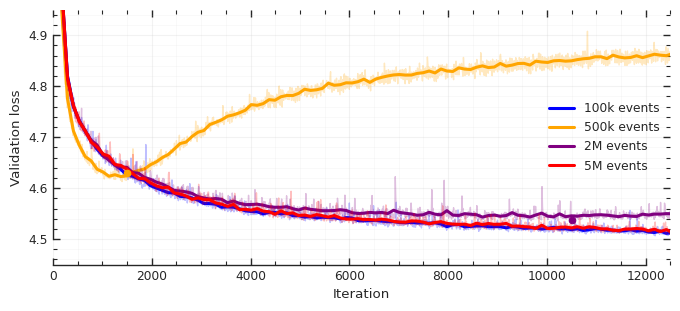

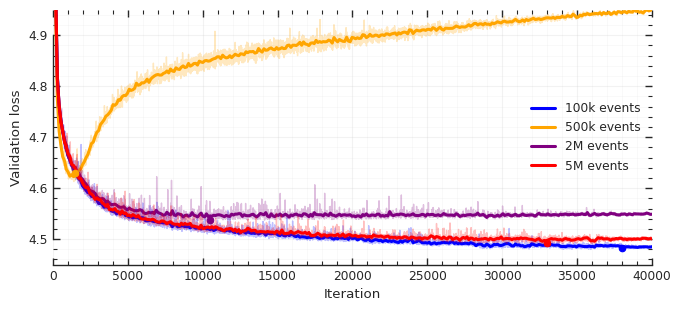

(<Figure size 690x320 with 1 Axes>,
 <Axes: xlabel='Iteration', ylabel='Validation loss'>)

In [154]:
titles = ['100k events', '500k events', '2M events', '5M events']
models = ['model_10M_9_exp9_vdi_2', 'model_exp10_500k_lr1', 'model_exp10_2M_lr1', 'model_exp10_5M_lr1']

plot_validation_run_pub(models, model_legend_title=titles, use_log=False, y_lim=(4.45, 4.95), x_lim=(0, 12500))
plot_validation_run_pub(models, model_legend_title=titles, use_log=False, y_lim=(4.45, 4.95), x_lim=(0, 40000))

eta all outgoing particles


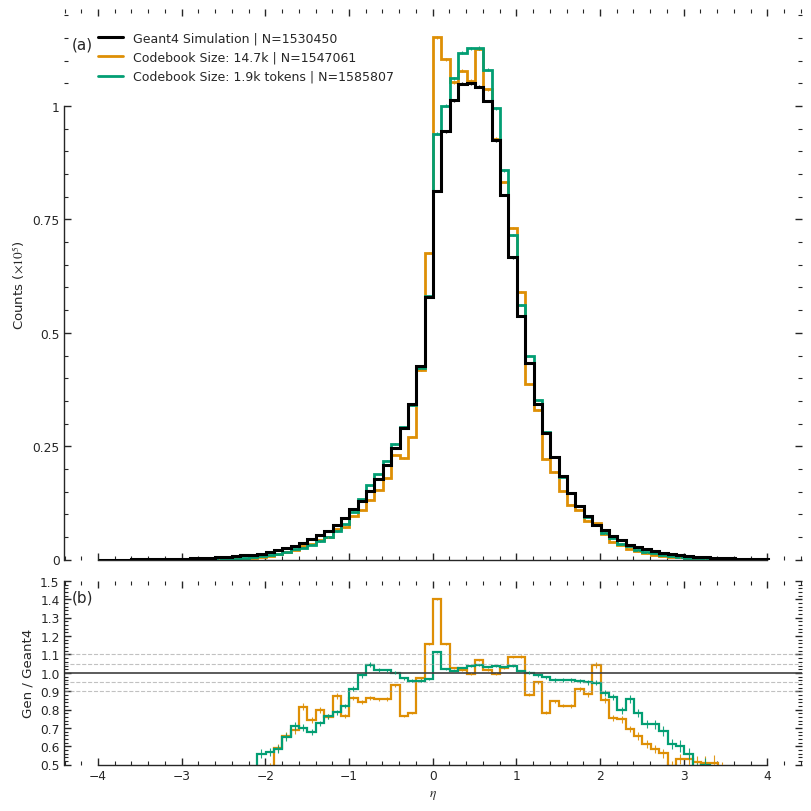

eta leading particles


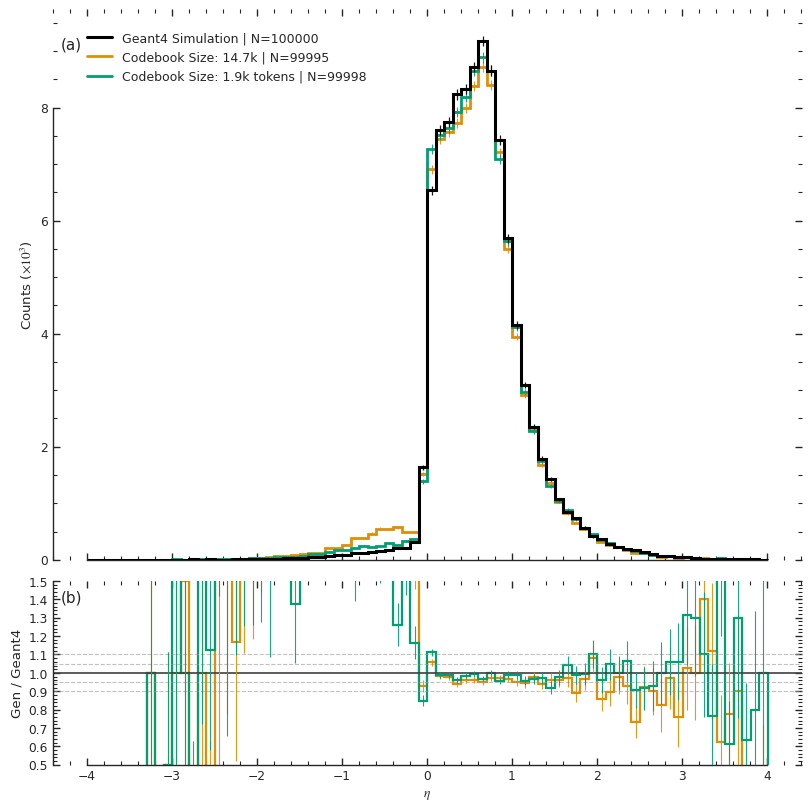

phi all outgoing particles


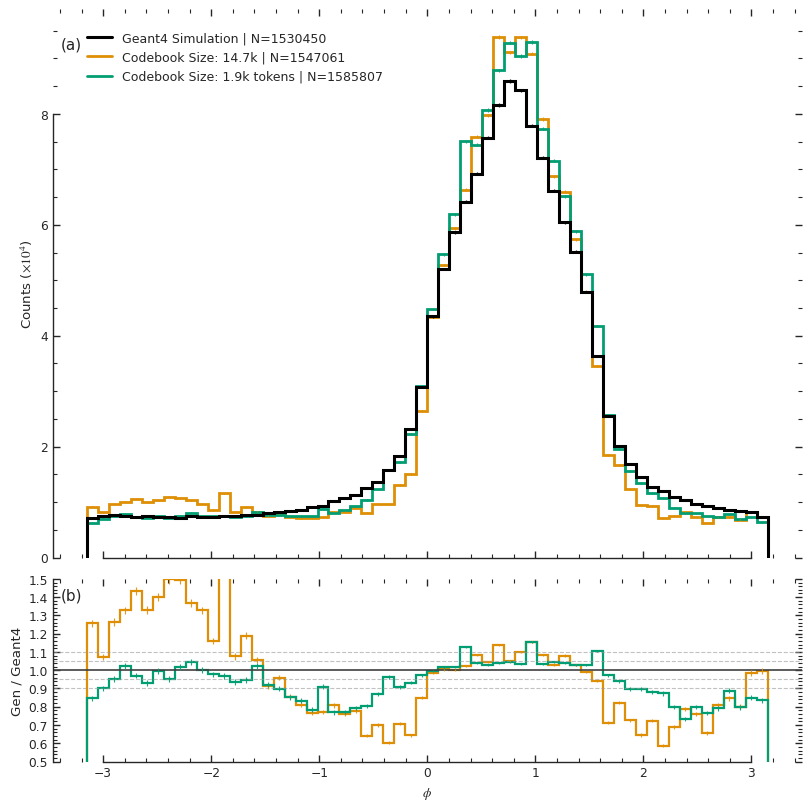

phi leading particles


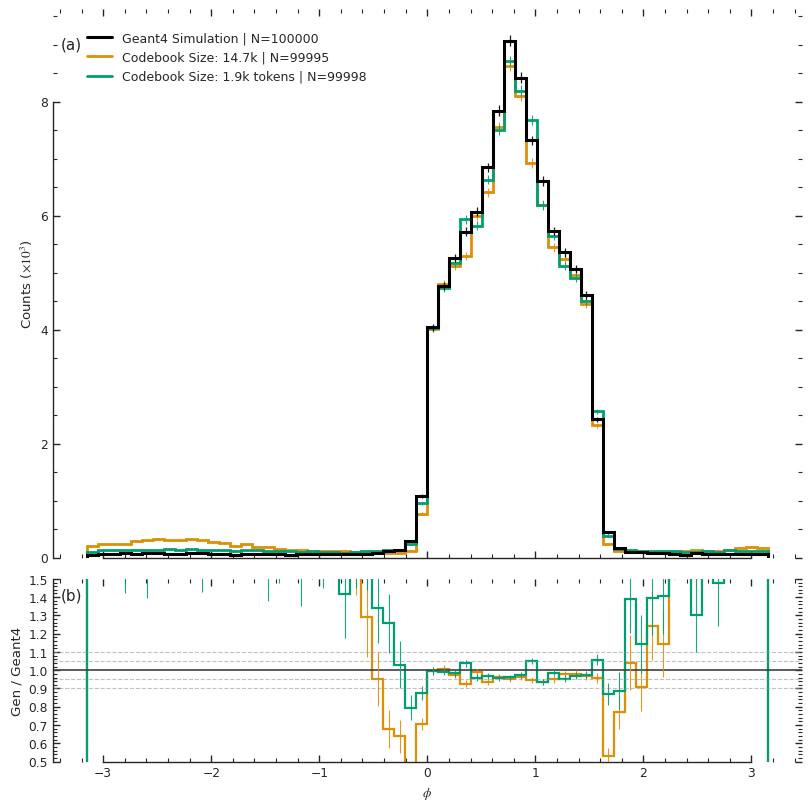

In [106]:
all_columns = ["pt", "eta", "phi"]
models_to_compare = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']
models_legend_title = ['Geant4 Simulation', 'Codebook Size: 14.7k', 'Codebook Size: 1.9k tokens']
for column in all_columns:
    print(f"{column} all outgoing particles")
    compare_distributions_all(
        model_names=models_to_compare,
        model_legend_titles=models_legend_title,
        column_name=column,
        normalized=False,
        use_log=False,
        out_file=parent_dir / 'temp' / f"proceeding_all_{column}.png")
    print(f"{column} leading particles")
    compare_distributions_leading(
        model_names=models_to_compare,
        model_legend_titles=models_legend_title,
        column_name=column, 
        normalized=False,
        use_log=False,
        out_file=parent_dir / 'temp' / f"proceeding_leading_{column}.png")
    # compare_distributions_leading(models_to_compare, models_legend_title, column, normalized=False, use_log=True, out_file=parent_dir / 'temp' / f"proceeding_leading_log_{column}.png")